# Gabarito — Quadriláteros: Definição, Elementos e Trapézios

Este notebook traz a resolução comentada dos exercícios de [`0408a_quadrilateros_definicao_elementos_e_trapezios.ipynb`](0408a_quadrilateros_definicao_elementos_e_trapezios.ipynb).

⚠️ **Antes de olhar aqui:** tente resolver os exercícios sozinho no notebook original e use as células de verificação (`assert`) para conferir sua resposta. Volte a este gabarito só depois de tentar — ou se travar de verdade em algum passo.

In [1]:
# Imports necessários para os exercícios abaixo.
import math

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Polygon

# Paleta de cores Nord
NORD_FUNDO = "#2E3440"
NORD_LINHA = "#4C566A"
NORD_TEXTO = "#ECEFF4"
NORD_TEXTO_SEC = "#D8DEE9"
COR_PONTO = "#88C0D0"
COR_DESTAQUE = "#A3BE8C"
COR_SECUNDARIA = "#81A1C1"
COR_EXTRA = "#B48EAD"
COR_AVISO = "#EBCB8B"


def estilizar_eixo(ax) -> None:
    """Aplica o estilo Nord padrão a um eixo do matplotlib."""
    ax.set_facecolor(NORD_FUNDO)
    ax.tick_params(colors=NORD_TEXTO_SEC)
    for spine in ax.spines.values():
        spine.set_color(NORD_LINHA)
    ax.grid(color=NORD_LINHA, linewidth=0.5, alpha=0.5)


# Ferramentas do notebook principal (reconstruídas aqui).
def direcao_de(origem, destino) -> float:
    """Direção, em graus, em que `destino` está quando visto de `origem`."""
    return math.degrees(math.atan2(destino[1] - origem[1], destino[0] - origem[0]))


def medir_angulo(vertice, P, Q) -> float:
    """Transferidor digital: medida, em graus, do ângulo com vértice em `vertice` entre P e Q."""
    u = np.subtract(P, vertice)
    v = np.subtract(Q, vertice)
    cosseno = np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v))
    return math.degrees(math.acos(np.clip(cosseno, -1, 1)))


def ponto_medio(P, Q) -> np.ndarray:
    """Ponto médio do segmento PQ: a média das coordenadas."""
    return (np.asarray(P, dtype=float) + np.asarray(Q, dtype=float)) / 2


def preparar_eixo(ax, pontos, margem: float = 0.8) -> None:
    """Eixo no estilo Nord, sem grade e sem números, com escala igual, enquadrando os `pontos`."""
    estilizar_eixo(ax)
    ax.grid(False)
    xs = [p[0] for p in pontos]
    ys = [p[1] for p in pontos]
    ax.set_xlim(min(xs) - margem, max(xs) + margem)
    ax.set_ylim(min(ys) - margem, max(ys) + margem)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])


def marcar_congruentes(ax, P, Q, tracos: int = 1, cor: str = NORD_TEXTO, tamanho: float = 0.16) -> None:
    """Tracinhos no meio do segmento PQ: a marca de segmentos congruentes."""
    P, Q = np.asarray(P, dtype=float), np.asarray(Q, dtype=float)
    u = (Q - P) / np.linalg.norm(Q - P)
    normal = np.array([-u[1], u[0]])
    meio = (P + Q) / 2
    for k in range(tracos):
        centro_traco = meio + (k - (tracos - 1) / 2) * 0.12 * u
        ax.plot(*zip(centro_traco - tamanho * normal, centro_traco + tamanho * normal), color=cor, lw=2, zorder=6)


# Figuras dadas nos enunciados.
trapezio_3 = [np.array(v, dtype=float) for v in [(0, 0), (10, 0), (7, 4), (3, 4)]]
triangulo_6 = [np.array(v, dtype=float) for v in [(0, 0), (8, 2), (3, 6)]]

## Básico

**Exercício 1.** O ângulo que falta num quadrilátero, conhecidos os outros três (e o quarto canto de um terreno com cantos de 80°, 95° e 120°).

In [2]:
def angulo_faltante_ex1(angulo_1: float, angulo_2: float, angulo_3: float) -> float:
    """Quarto ângulo interno de um quadrilátero, conhecidos os outros três."""
    # Os quatro ângulos internos somam 360° (uma diagonal divide o quadrilátero em 2 triângulos):
    # o que falta é o que sobra de 360°.
    return 360 - (angulo_1 + angulo_2 + angulo_3)


quarto_canto_ex1 = angulo_faltante_ex1(80, 95, 120)  # 360 − 295 = 65

for angulos in [(90, 90, 90), (80, 95, 120), (100, 100, 100), (45.5, 134.5, 90), (200, 50, 60)]:
    print(f"{angulos}  ->  quarto ângulo = {angulo_faltante_ex1(*angulos):g}°")
print(f"\nquarto canto do terreno: {quarto_canto_ex1}°")
# O último caso tem um ângulo de 200°: é um quadrilátero côncavo, e a soma continua 360°.

(90, 90, 90)  ->  quarto ângulo = 90°
(80, 95, 120)  ->  quarto ângulo = 65°
(100, 100, 100)  ->  quarto ângulo = 60°
(45.5, 134.5, 90)  ->  quarto ângulo = 90°
(200, 50, 60)  ->  quarto ângulo = 50°

quarto canto do terreno: 65°


**Exercício 2.** Classificar um trapézio pelos lados não paralelos e pelos ângulos da base maior.

In [3]:
def classificar_trapezio_ex2(lateral_1: float, lateral_2: float, angulo_A: float, angulo_B: float) -> str:
    """'retângulo', 'isósceles' ou 'escaleno'."""
    # 1º) Um ângulo reto na base maior: um lado não paralelo é perpendicular às bases.
    #     (Basta olhar a base maior: se Â = 90°, então D̂ = 180° − 90° = 90° também, pelos colaterais.)
    if math.isclose(angulo_A, 90) or math.isclose(angulo_B, 90):
        return "retângulo"
    # 2º) Lados não paralelos congruentes. math.isclose evita a armadilha de 0.1 + 0.2 != 0.3.
    if math.isclose(lateral_1, lateral_2):
        return "isósceles"
    # 3º) Nenhum dos dois casos.
    return "escaleno"


for caso in [(5, 5, 60, 60), (4, 5, 90, 53.13), (3, 6, 70, 30), (0.1 + 0.2, 0.3, 75, 75), (2, 2.5, 80, 65)]:
    print(f"laterais {caso[0]:g} e {caso[1]:g}, ângulos {caso[2]}° e {caso[3]}°  ->  {classificar_trapezio_ex2(*caso)}")
print(f"\n0.1 + 0.2 == 0.3?  {0.1 + 0.2 == 0.3}   (por isso usamos math.isclose)")

laterais 5 e 5, ângulos 60° e 60°  ->  isósceles
laterais 4 e 5, ângulos 90° e 53.13°  ->  retângulo
laterais 3 e 6, ângulos 70° e 30°  ->  escaleno
laterais 0.3 e 0.3, ângulos 75° e 75°  ->  isósceles
laterais 2 e 2.5, ângulos 80° e 65°  ->  escaleno

0.1 + 0.2 == 0.3?  False   (por isso usamos math.isclose)


## Intermediário

**Exercício 3.** No trapézio isósceles $A = (0, 0)$, $B = (10, 0)$, $C = (7, 4)$, $D = (3, 4)$: os ângulos da base maior e a congruência dos triângulos formados pelas alturas.

In [4]:
A_ex3, B_ex3, C_ex3, D_ex3 = trapezio_3

# (a) Â fica entre os lados AB e AD; B̂, entre BA e BC.
angulo_A_ex3 = medir_angulo(A_ex3, B_ex3, D_ex3)
angulo_B_ex3 = medir_angulo(B_ex3, A_ex3, C_ex3)

# (b) As bases são horizontais, então a perpendicular a AB por D é vertical: o pé tem o mesmo x de D
#     e y = 0. O mesmo vale para C.
H1_ex3 = np.array([D_ex3[0], 0.0])  # (3, 0)
H2_ex3 = np.array([C_ex3[0], 0.0])  # (7, 0)

# (c) Os três lados de cada triângulo retângulo, em ordem crescente.
lados_AH1D_ex3 = sorted([math.dist(A_ex3, H1_ex3), math.dist(H1_ex3, D_ex3), math.dist(D_ex3, A_ex3)])
lados_BH2C_ex3 = sorted([math.dist(B_ex3, H2_ex3), math.dist(H2_ex3, C_ex3), math.dist(C_ex3, B_ex3)])

# (d) Os mesmos três lados (3, 4 e 5, o famoso triângulo 3-4-5): congruentes pelo caso LLL.
congruentes_ex3 = np.allclose(lados_AH1D_ex3, lados_BH2C_ex3)
caso_ex3 = "LLL"

print(f"Â = {angulo_A_ex3:.4f}°,  B̂ = {angulo_B_ex3:.4f}°  ->  iguais, como o teorema garante")
print(f"H1 = {H1_ex3},  H2 = {H2_ex3}")
print(f"lados de AH1D: {lados_AH1D_ex3}")
print(f"lados de BH2C: {lados_BH2C_ex3}")
print(f"congruentes? {congruentes_ex3} (caso {caso_ex3})")
# Na demonstração da seção 4 usamos o caso hipotenusa-cateto (só sabíamos AD = BC e DH1 = CH2);
# aqui, com coordenadas, deu para medir os três lados e usar o LLL direto.

Â = 53.1301°,  B̂ = 53.1301°  ->  iguais, como o teorema garante
H1 = [3. 0.],  H2 = [7. 0.]
lados de AH1D: [3.0, 4.0, 5.0]
lados de BH2C: [3.0, 4.0, 5.0]
congruentes? True (caso LLL)


**Exercício 4.** Uma função para a base média de um trapézio dado pelos vértices, testada contra a fórmula.

In [5]:
def base_media_ex4(A, B, C, D) -> float:
    """Medida da base média do trapézio ABCD de bases AB e DC."""
    M = ponto_medio(A, D)  # ponto médio de um lado não paralelo
    N = ponto_medio(B, C)  # ponto médio do outro
    return math.dist(M, N)


casos = [
    [(0, 0), (8, 0), (6, 3), (2, 3)],
    [(0, 0), (10, 0), (7, 4), (3, 4)],
    [(0, 0), (7, 0), (3, 2.5), (0, 2.5)],
    [(1, 1), (1, 9), (4, 7), (4, 3)],
    [(0, 0), (8, 4), (5, 5), (1, 3)],
    [(0, 0), (6, 0), (4, 5), (4, 5)],
]
for vertices in casos:
    A, B, C, D = (np.array(v, dtype=float) for v in vertices)
    formula = (math.dist(A, B) + math.dist(D, C)) / 2
    print(f"{vertices}:  MN = {base_media_ex4(A, B, C, D):.4f},  (AB + DC)/2 = {formula:.4f}")
# A função não depende da posição do trapézio: funciona com bases verticais, inclinadas e até no
# triângulo (C = D), em que a base média é a metade de AB.

[(0, 0), (8, 0), (6, 3), (2, 3)]:  MN = 6.0000,  (AB + DC)/2 = 6.0000
[(0, 0), (10, 0), (7, 4), (3, 4)]:  MN = 7.0000,  (AB + DC)/2 = 7.0000
[(0, 0), (7, 0), (3, 2.5), (0, 2.5)]:  MN = 5.0000,  (AB + DC)/2 = 5.0000
[(1, 1), (1, 9), (4, 7), (4, 3)]:  MN = 6.0000,  (AB + DC)/2 = 6.0000
[(0, 0), (8, 4), (5, 5), (1, 3)]:  MN = 6.7082,  (AB + DC)/2 = 6.7082
[(0, 0), (6, 0), (4, 5), (4, 5)]:  MN = 3.0000,  (AB + DC)/2 = 3.0000


## Desafio

**Exercício 5.** O problema inverso: dadas a base média e uma das bases, encontrar a outra (e o fundo de uma calha com largura média de 9 cm e abertura de 13 cm).

In [6]:
def outra_base_ex5(base_media: float, base_conhecida: float) -> float | None:
    """Medida da outra base do trapézio, ou None se não existir trapézio com essas medidas."""
    # base_media = (base_conhecida + outra) / 2
    # 2 · base_media = base_conhecida + outra
    # outra = 2 · base_media − base_conhecida
    outra = 2 * base_media - base_conhecida
    # Um lado precisa ter medida positiva. Com outra = 0 a figura seria um triângulo, e com outra < 0
    # a base média seria menor que a metade da base conhecida, o que é impossível.
    return outra if outra > 0 else None


fundo_calha_ex5 = outra_base_ex5(9, 13)  # 2 × 9 − 13 = 5

for media, conhecida in [(7, 10), (7, 4), (9, 13), (6.5, 2), (3, 8), (4, 8)]:
    print(f"base média {media:g}, uma base {conhecida:g}  ->  outra base = {outra_base_ex5(media, conhecida)}")
print(f"\nfundo da calha: {fundo_calha_ex5} cm")
# Repare nos dois primeiros casos: a função não precisa saber se a base conhecida é a maior ou a menor.

base média 7, uma base 10  ->  outra base = 4
base média 7, uma base 4  ->  outra base = 10
base média 9, uma base 13  ->  outra base = 5
base média 6.5, uma base 2  ->  outra base = 11.0
base média 3, uma base 8  ->  outra base = None
base média 4, uma base 8  ->  outra base = None

fundo da calha: 5 cm


**Exercício 6.** A base média do triângulo $A = (0, 0)$, $B = (8, 2)$, $C = (3, 6)$, conferida com inclinações e distâncias, e depois em 1000 triângulos sorteados.

In [7]:
A_ex6, B_ex6, C_ex6 = triangulo_6
gerador_ex6 = np.random.default_rng(6)

# (a) Pontos médios de AB e de AC.
M_ex6 = ponto_medio(A_ex6, B_ex6)  # (4, 1)
N_ex6 = ponto_medio(A_ex6, C_ex6)  # (1.5, 3)

# (b) Inclinações: as duas saem iguais (M → N aponta no mesmo sentido de B → C).
inclinacao_MN_ex6 = direcao_de(M_ex6, N_ex6)
inclinacao_BC_ex6 = direcao_de(B_ex6, C_ex6)
diferenca = (inclinacao_MN_ex6 - inclinacao_BC_ex6) % 180
paralelos_ex6 = math.isclose(diferenca, 0, abs_tol=1e-9) or math.isclose(diferenca, 180, abs_tol=1e-9)

# (c) A razão entre as medidas.
razao_ex6 = math.dist(M_ex6, N_ex6) / math.dist(B_ex6, C_ex6)


# (d) O mesmo teste em 1000 triângulos sorteados.
def base_media_confere(A, B, C) -> bool:
    """True se o segmento dos pontos médios de AB e AC é paralelo a BC e mede metade dele."""
    M, N = ponto_medio(A, B), ponto_medio(A, C)
    diferenca = (direcao_de(M, N) - direcao_de(B, C)) % 180
    paralelo = math.isclose(diferenca, 0, abs_tol=1e-9) or math.isclose(diferenca, 180, abs_tol=1e-9)
    return paralelo and math.isclose(math.dist(M, N), math.dist(B, C) / 2)


todos_ok_ex6 = all(base_media_confere(*gerador_ex6.uniform(-10, 10, (3, 2))) for _ in range(1000))

print(f"M = {M_ex6},  N = {N_ex6}")
print(f"inclinação de MN = {inclinacao_MN_ex6:.4f}°,  inclinação de BC = {inclinacao_BC_ex6:.4f}°  ->  paralelos? {paralelos_ex6}")
print(f"MN = {math.dist(M_ex6, N_ex6):.4f},  BC = {math.dist(B_ex6, C_ex6):.4f},  MN/BC = {razao_ex6:.4f}")
print(f"1000 triângulos sorteados, todos conferem? {todos_ok_ex6}")

M = [4. 1.],  N = [1.5 3. ]
inclinação de MN = 141.3402°,  inclinação de BC = 141.3402°  ->  paralelos? True
MN = 3.2016,  BC = 6.4031,  MN/BC = 0.5000
1000 triângulos sorteados, todos conferem? True


**A demonstração (para todo triângulo).** Os 1000 testes dão confiança, mas não são uma prova. A prova usa a mesma estratégia de [`0405a_congruencia_de_triangulos.ipynb`](0405a_congruencia_de_triangulos.ipynb): construir triângulos congruentes.

No triângulo $ABC$, $M$ é o ponto médio de $\overline{AB}$ e $N$ o de $\overline{AC}$. **Prolongue** $\overline{MN}$ além de $N$ até um ponto $P$ tal que $NP = MN$ (a figura abaixo mostra a construção).

| Passo | Afirmação | Justificativa |
|---|---|---|
| 1 | $AN = NC$ | $N$ é o ponto médio de $\overline{AC}$ |
| 2 | $MN = NP$ | construção |
| 3 | $A\hat{N}M \equiv C\hat{N}P$ | opostos pelo vértice (0403a) |
| 4 | $\triangle ANM \equiv \triangle CNP$ | LAL (passos 1, 3 e 2) |
| 5 | $CP = AM = MB$ | passo 4 e $M$ ponto médio de $\overline{AB}$ |
| 6 | $M\hat{A}N \equiv P\hat{C}N$, logo $\overleftrightarrow{CP} \parallel \overleftrightarrow{AB}$ | passo 4; são alternos internos (transversal $\overleftrightarrow{AC}$), e a recíproca de 0406a garante o paralelismo |
| 7 | $B\hat{M}C \equiv P\hat{C}M$ | alternos internos: $\overleftrightarrow{AB} \parallel \overleftrightarrow{CP}$ cortadas pela transversal $\overleftrightarrow{MC}$ (0406a) |
| 8 | $\triangle BMC \equiv \triangle PCM$ | LAL: $MB = CP$ (passo 5), ângulo do passo 7 e o lado comum $\overline{MC}$ |
| 9 | $BC = PM$ e $B\hat{C}M \equiv P\hat{M}C$ | passo 8 (elementos correspondentes) |
| 10 | $\overline{MN} \parallel \overline{BC}$ | passo 9: alternos internos congruentes (transversal $\overleftrightarrow{MC}$), recíproca de 0406a |
| 11 | $MN = \dfrac{MP}{2} = \dfrac{BC}{2}$ | passos 2 e 9 ∎ |

Repare que o quadrilátero $MBCP$ da construção tem os lados opostos $\overline{MB}$ e $\overline{CP}$ paralelos **e** congruentes. No próximo notebook, [`0409a_paralelogramos_e_casos_particulares.ipynb`](0409a_paralelogramos_e_casos_particulares.ipynb), você vai ver que isso basta para ele ser um paralelogramo.

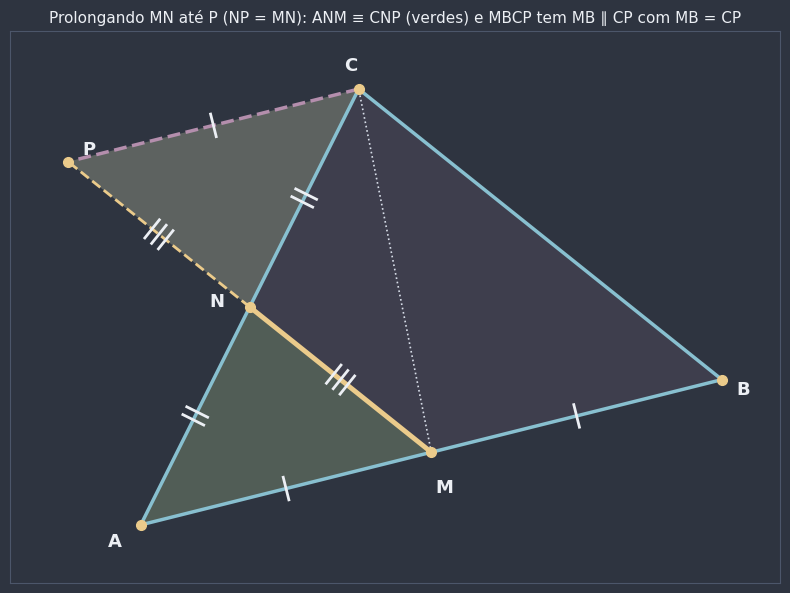

P = [-1.  5.],  CP = 4.1231,  MB = 4.1231,  MP = 6.4031,  BC = 6.4031


In [8]:
A, B, C = triangulo_6
M, N = ponto_medio(A, B), ponto_medio(A, C)
P = 2 * N - M  # prolongando MN além de N: N é o ponto médio de MP

fig, ax = plt.subplots(figsize=(8, 6.5))
fig.patch.set_facecolor(NORD_FUNDO)
preparar_eixo(ax, [A, B, C, P], margem=0.8)
ax.add_patch(Polygon([A, N, M], closed=True, facecolor=COR_DESTAQUE, alpha=0.3, edgecolor="none"))
ax.add_patch(Polygon([C, N, P], closed=True, facecolor=COR_DESTAQUE, alpha=0.3, edgecolor="none"))
ax.add_patch(Polygon([M, B, C, P], closed=True, facecolor=COR_EXTRA, alpha=0.12, edgecolor="none"))
for X, Y in ((A, B), (B, C), (C, A)):
    ax.plot(*zip(X, Y), color=COR_PONTO, lw=2.5)
ax.plot(*zip(M, N), color=COR_AVISO, lw=3.5)
ax.plot(*zip(N, P), color=COR_AVISO, lw=2, linestyle="--")
ax.plot(*zip(C, P), color=COR_EXTRA, lw=2.5, linestyle="--")
ax.plot(*zip(M, C), color=NORD_TEXTO_SEC, lw=1.2, linestyle=":")
for X, Y, tracos in ((A, M, 1), (M, B, 1), (C, P, 1), (A, N, 2), (N, C, 2), (M, N, 3), (N, P, 3)):
    marcar_congruentes(ax, X, Y, tracos)
for X, nome, deslocamento in ((A, "A", (-0.45, -0.3)), (B, "B", (0.2, -0.2)), (C, "C", (-0.2, 0.25)),
                              (M, "M", (0.05, -0.55)), (N, "N", (-0.55, 0.0)), (P, "P", (0.2, 0.1))):
    ax.plot(*X, "o", color=COR_AVISO, markersize=7, zorder=7)
    ax.text(X[0] + deslocamento[0], X[1] + deslocamento[1], nome, color=NORD_TEXTO, fontsize=13, fontweight="bold")
ax.set_title("Prolongando MN até P (NP = MN): ANM ≡ CNP (verdes) e MBCP tem MB ∥ CP com MB = CP",
             color=NORD_TEXTO, fontsize=11)
plt.tight_layout()
plt.show()
print(f"P = {P},  CP = {math.dist(C, P):.4f},  MB = {math.dist(M, B):.4f},  MP = {math.dist(M, P):.4f},  "
      f"BC = {math.dist(B, C):.4f}")